In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path


def load_roi(path="mihi_roi_postel_px.npz"):
    d = np.load(path)

    return {
        "px": d["px"],
        "py": d["py"],
        "map_shape": tuple(d["map_shape"]),
        "lon_carr": float(d["lon_carr"]),
        "lat_carr": float(d["lat_carr"]),
    }


def check_shape(emap, shape_ref):
    if emap.shape != shape_ref:
        raise ValueError(
            f"Mapa {emap.shape} ≠ mapa de referencia {shape_ref}"
        )


def roi_mask(px, py, shape):
    """
    Máscara booleana.
    True para los píxeles cuyo centro está dentro de la ROI.
    """
    ny, nx = shape

    yy, xx = np.mgrid[0:ny, 0:nx]

    poly = Path(
        np.column_stack([px, py])
    )

    inside = poly.contains_points(
        np.column_stack([
            xx.ravel(),
            yy.ravel()
        ])
    )

    return inside.reshape(shape)


def plot_roi(ax, px, py, **kw):

    kw.setdefault("color", "cyan")
    kw.setdefault("lw", 1.5)

    ax.plot(px, py, **kw)

In [3]:
roi = load_roi("mihi_roi_postel_px.npz")

px_roi = roi["px"]
py_roi = roi["py"]
shape_roi = roi["map_shape"]

print("Mapa de referencia:", shape_roi)
print("Centro aproximado Carrington:")
print("L =", roi["lon_carr"])
print("B =", roi["lat_carr"])

Mapa de referencia: (np.int64(1024), np.int64(1024))
Centro aproximado Carrington:
L = 106.24285436646456
B = 9.4939136059252


In [4]:
from astropy.io import fits
import os

folder="../data/2018_08_25"
egression_file = os.path.join(folder,"egress_pwr_06.0-07.0mHz_z0000km.fits")

with fits.open(egression_file) as hdul:
    egression_data = hdul[0].data

check_shape(egression_data, shape_roi)

mask = roi_mask(
    px_roi,
    py_roi,
    egression_data.shape
)

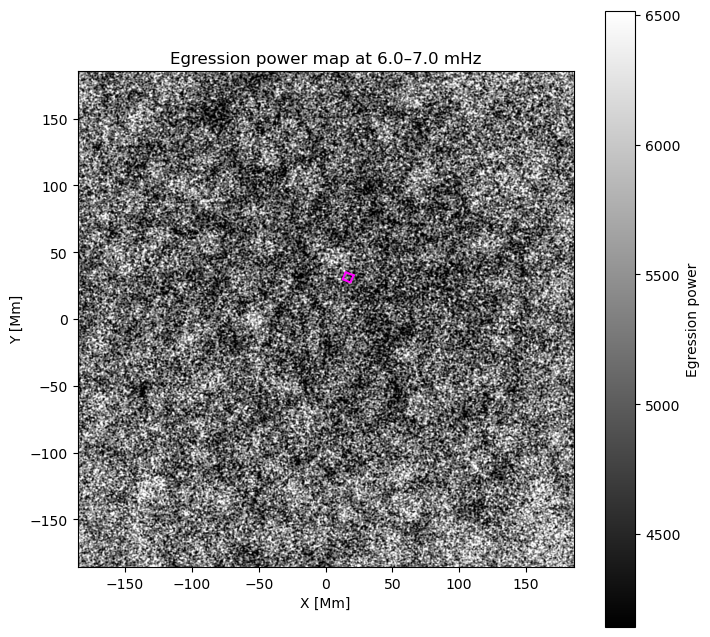

In [5]:
# Spatial sampling, here I assume it is the same as the HMI spatial sample (0.5'' per pixel & 725Km per arcsec)
spatial_sample = 0.5 * 725 * 0.001  # Mm/pixel

ny, nx = egression_data.shape

# Physical dimensions of the map, with the origin at the center of the image

x_min = -nx / 2 * spatial_sample
x_max =  nx / 2 * spatial_sample
y_min = -ny / 2 * spatial_sample
y_max =  ny / 2 * spatial_sample
extent = [x_min, x_max, y_min, y_max]

x_roi_Mm = (px_roi - nx/2) * spatial_sample
y_roi_Mm = (py_roi - ny/2) * spatial_sample

fig, ax = plt.subplots(figsize=(8, 8))

vmin=np.percentile(egression_data,5)
vmax=np.percentile(egression_data,98)

im = ax.imshow(
    egression_data,
    origin="lower",
    cmap="gray",
    extent=extent,
    vmin=vmin,
    vmax=vmax
)

plot_roi(
    ax,
    x_roi_Mm,
    y_roi_Mm,
    color="magenta",
)

fig.colorbar(
    im,
    ax=ax,
    label="Egression power"
)

ax.set_xlabel("X [Mm]")
ax.set_ylabel("Y [Mm]")
ax.set_title("Egression power map at 6.0–7.0 mHz")

plt.show()

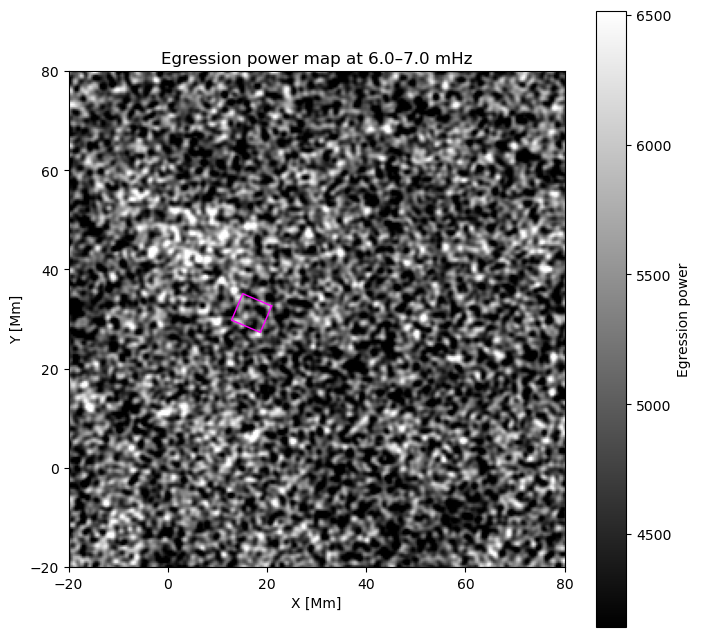

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

# ============================================================
# MAPA DE POTENCIA DE EGRESIÓN
# ============================================================

im = ax.imshow(
    egression_data,
    origin="lower",
    cmap="gray",
    extent=extent,
    vmin=vmin,
    vmax=vmax
)

# ============================================================
# ROI MiHI
# ============================================================

plot_roi(
    ax,
    x_roi_Mm,
    y_roi_Mm,
    color="magenta",
    lw=1
)

# ============================================================
# RECORTE ESPACIAL: 0–50 Mm
# ============================================================

ax.set_xlim(-20, 80)
ax.set_ylim(-20, 80)

# ============================================================
# FORMATO
# ============================================================

fig.colorbar(
    im,
    ax=ax,
    label="Egression power"
)

ax.set_xlabel("X [Mm]")
ax.set_ylabel("Y [Mm]")
ax.set_title("Egression power map at 6.0–7.0 mHz")

plt.show()

In [7]:
import os
import numpy as np
from astropy.io import fits

base_path = "../data/2018_08_25"

files = {
    "2.0-3.0 mHz": "egress_pwr_02.0-03.0mHz_z0000km.fits",
    "3.0-4.0 mHz": "egress_pwr_03.0-04.0mHz_z0000km.fits",
    "4.0-5.0 mHz": "egress_pwr_04.0-05.0mHz_z0000km.fits",
    "5.0-6.0 mHz": "egress_pwr_05.0-06.0mHz_z0000km.fits",
    "6.0-7.0 mHz": "egress_pwr_06.0-07.0mHz_z0000km.fits",
    "7.0-8.0 mHz": "egress_pwr_07.0-08.0mHz_z0000km.fits",
    "8.0-9.0 mHz": "egress_pwr_08.0-09.0mHz_z0000km.fits",
    "9.0-10.0 mHz": "egress_pwr_09.0-10.0mHz_z0000km.fits",
    "10.0-11.0 mHz": "egress_pwr_10.0-11.0mHz_z0000km.fits",
}
frequencies = list(files.keys())

egression_maps = []

for freq_band, filename in files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data_map = hdul[0].data.copy()

    egression_maps.append(data_map)

print("Number of maps:", len(egression_maps))
print("Shape of first map:", egression_maps[0].shape)

Number of maps: 9
Shape of first map: (1024, 1024)


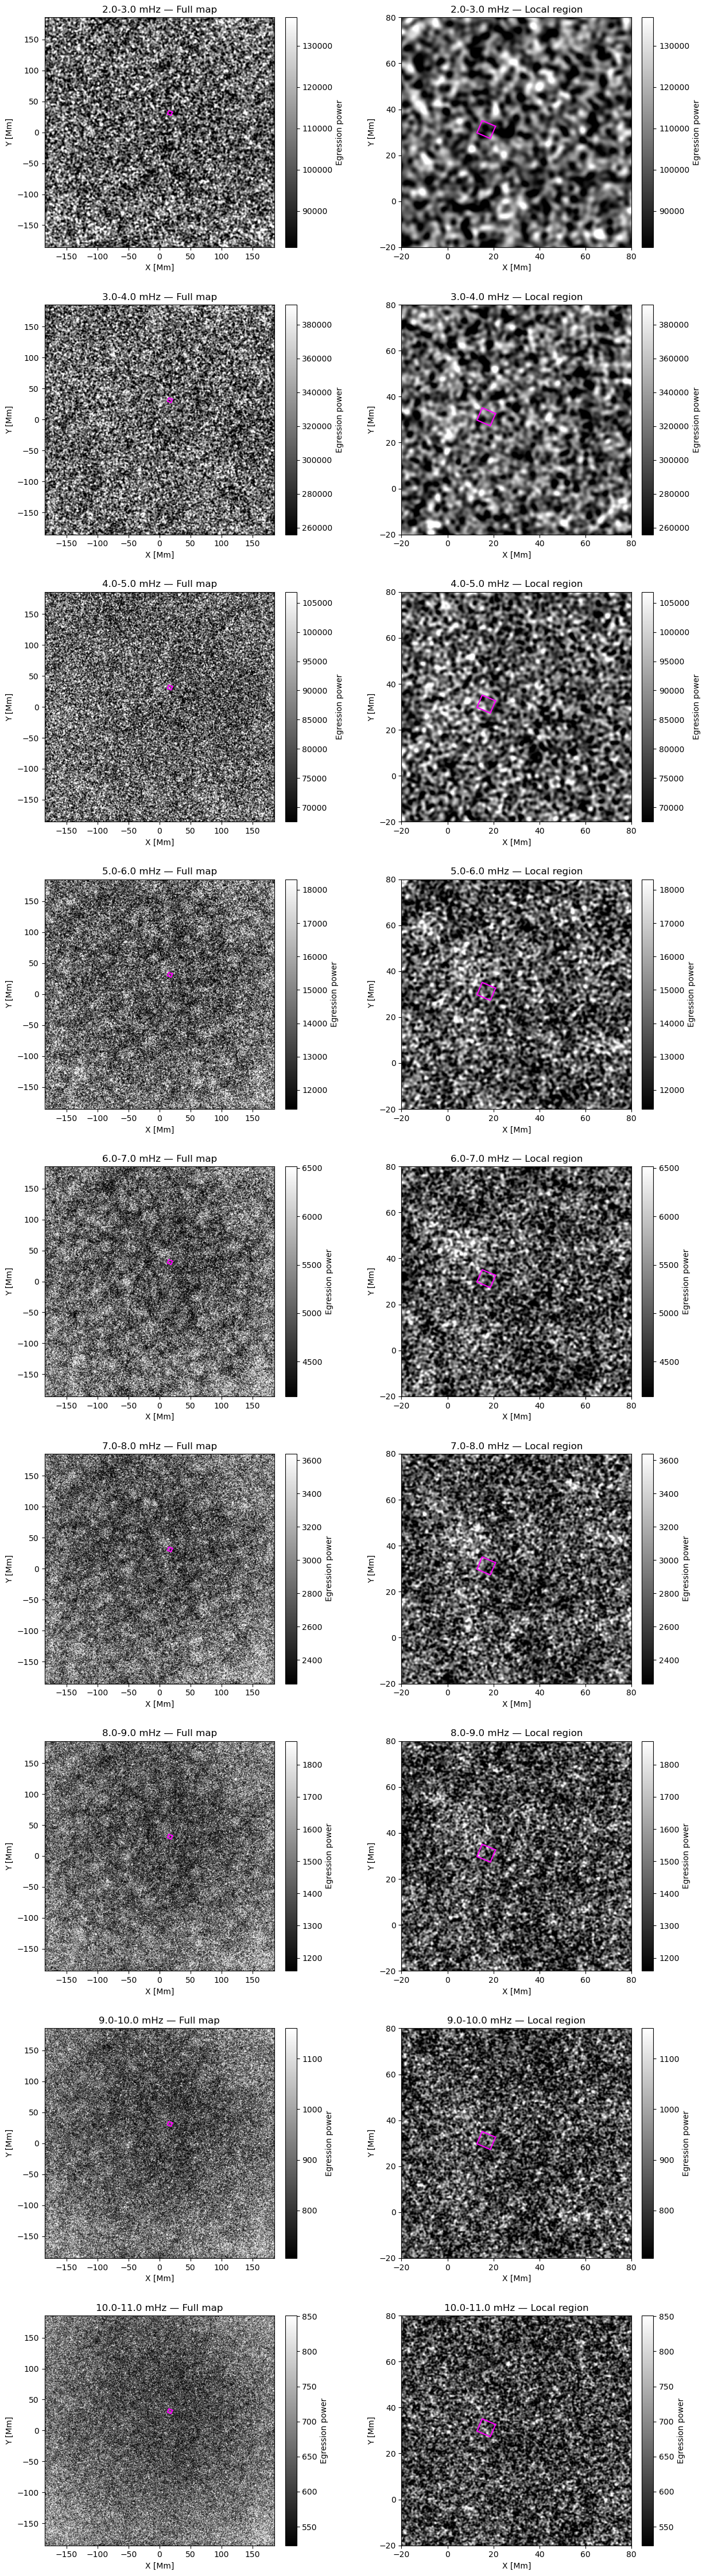

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# ESCALA ESPACIAL
# ============================================================

# HMI: 0.5 arcsec/pixel
# Escala solar aproximada: 725 km/arcsec
spatial_sample = 0.5 * 725 * 0.001  # Mm/pixel


# ============================================================
# GEOMETRÍA DEL MAPA
# ============================================================

ny, nx = egression_maps[0].shape

x_min = -nx / 2 * spatial_sample
x_max =  nx / 2 * spatial_sample
y_min = -ny / 2 * spatial_sample
y_max =  ny / 2 * spatial_sample

extent = [x_min, x_max, y_min, y_max]


# ============================================================
# ROI: PÍXELES POSTEL → Mm
# ============================================================

x_roi_Mm = (px_roi - nx / 2) * spatial_sample
y_roi_Mm = (py_roi - ny / 2) * spatial_sample


# ============================================================
# FIGURA
# ============================================================

n_maps = len(egression_maps)

fig, axes = plt.subplots(
    nrows=n_maps,
    ncols=2,
    figsize=(12, 5 * n_maps)
)


# ============================================================
# GRAFICAR CADA BANDA DE FRECUENCIA
# ============================================================

for i, (freq, data_map) in enumerate(
    zip(frequencies, egression_maps)
):

    # --------------------------------------------------------
    # CONTRASTE PARA ESTA BANDA
    # --------------------------------------------------------

    vmin = np.nanpercentile(data_map, 5)
    vmax = np.nanpercentile(data_map, 98)


    # ========================================================
    # COLUMNA 1: MAPA COMPLETO
    # ========================================================

    ax_full = axes[i, 0]

    im_full = ax_full.imshow(
        data_map,
        origin="lower",
        cmap="gray",
        extent=extent,
        vmin=vmin,
        vmax=vmax
    )

    plot_roi(
        ax_full,
        x_roi_Mm,
        y_roi_Mm,
        color="magenta",
        lw=1.5
    )

    ax_full.set_xlabel("X [Mm]")
    ax_full.set_ylabel("Y [Mm]")
    ax_full.set_title(
        f"{freq} — Full map"
    )

    fig.colorbar(
        im_full,
        ax=ax_full,
        label="Egression power",
        fraction=0.046,
        pad=0.04
    )


    # ========================================================
    # COLUMNA 2: REGIÓN LOCAL
    # ========================================================

    ax_zoom = axes[i, 1]

    im_zoom = ax_zoom.imshow(
        data_map,
        origin="lower",
        cmap="gray",
        extent=extent,
        vmin=vmin,
        vmax=vmax
    )

    plot_roi(
        ax_zoom,
        x_roi_Mm,
        y_roi_Mm,
        color="magenta",
        lw=1.5
    )

    # Zoom espacial
    ax_zoom.set_xlim(-20, 80)
    ax_zoom.set_ylim(-20, 80)

    ax_zoom.set_xlabel("X [Mm]")
    ax_zoom.set_ylabel("Y [Mm]")
    ax_zoom.set_title(
        f"{freq} — Local region"
    )

    fig.colorbar(
        im_zoom,
        ax=ax_zoom,
        label="Egression power",
        fraction=0.046,
        pad=0.04
    )


# ============================================================
# AJUSTAR ESPACIADO
# ============================================================

plt.tight_layout()

# Más separación entre las dos columnas
fig.subplots_adjust(
    wspace=0.35,
    hspace=0.25
)

plt.show()

## Mean value of the cropped egression power maps

In [22]:
import os
import numpy as np
from astropy.io import fits

base_path = "../data/2018_08_25"

cropped_files = {
    "2.0-3.0 mHz":  "egress_pwr_02.0-03.0mHz_z0000km_cropped.fits",
    "3.0-4.0 mHz":  "egress_pwr_03.0-04.0mHz_z0000km_cropped.fits",
    "4.0-5.0 mHz":  "egress_pwr_04.0-05.0mHz_z0000km_cropped.fits",
    "5.0-6.0 mHz":  "egress_pwr_05.0-06.0mHz_z0000km_cropped.fits",
    "6.0-7.0 mHz":  "egress_pwr_06.0-07.0mHz_z0000km_cropped.fits",
    "7.0-8.0 mHz":  "egress_pwr_07.0-08.0mHz_z0000km_cropped.fits",
    "8.0-9.0 mHz":  "egress_pwr_08.0-09.0mHz_z0000km_cropped.fits",
    "9.0-10.0 mHz": "egress_pwr_09.0-10.0mHz_z0000km_cropped.fits",
    "10.0-11.0 mHz":"egress_pwr_10.0-11.0mHz_z0000km_cropped.fits",
}

cropped_frequencies = list(cropped_files.keys())
cropped_maps = []

for freq_band, filename in cropped_files.items():

    path = os.path.join(base_path, filename)

    with fits.open(path) as hdul:
        data_map = hdul[0].data.copy()

    cropped_maps.append(data_map)

    n_total = data_map.size
    n_nan   = np.isnan(data_map).sum()
    n_zero  = np.sum(data_map == 0)
    n_finite = np.isfinite(data_map).sum()

    print(f"\n{freq_band}")
    print(f"  Shape:         {data_map.shape}")
    print(f"  Total pixels:  {n_total}")
    print(f"  NaN:           {n_nan}")
    print(f"  Zeros:         {n_zero}")
    print(f"  Finite:        {n_finite}")

print("\nNumber of cropped maps:", len(cropped_maps))


2.0-3.0 mHz
  Shape:         (1024, 1024)
  Total pixels:  1048576
  NaN:           0
  Zeros:         565551
  Finite:        1048576

3.0-4.0 mHz
  Shape:         (1024, 1024)
  Total pixels:  1048576
  NaN:           0
  Zeros:         565551
  Finite:        1048576

4.0-5.0 mHz
  Shape:         (1024, 1024)
  Total pixels:  1048576
  NaN:           0
  Zeros:         565551
  Finite:        1048576

5.0-6.0 mHz
  Shape:         (1024, 1024)
  Total pixels:  1048576
  NaN:           0
  Zeros:         565551
  Finite:        1048576

6.0-7.0 mHz
  Shape:         (1024, 1024)
  Total pixels:  1048576
  NaN:           0
  Zeros:         565551
  Finite:        1048576

7.0-8.0 mHz
  Shape:         (1024, 1024)
  Total pixels:  1048576
  NaN:           0
  Zeros:         565551
  Finite:        1048576

8.0-9.0 mHz
  Shape:         (1024, 1024)
  Total pixels:  1048576
  NaN:           0
  Zeros:         565551
  Finite:        1048576

9.0-10.0 mHz
  Shape:         (1024, 1024)
  To

## Comprueba que no hayan ceros dentro de la región recortada

In [23]:
import os
import numpy as np
from astropy.io import fits

# ============================================================
# COMPROBAR CEROS DENTRO DE LA REGIÓN VÁLIDA
# PARA TODOS LOS MAPAS
# ============================================================

for freq, cropped_filename in cropped_files.items():

    # Obtener el nombre del mapa original
    original_filename = cropped_filename.replace(
        "_cropped.fits",
        ".fits"
    )

    # --------------------------------------------------------
    # Cargar mapa original y mapa recortado
    # --------------------------------------------------------

    original = fits.getdata(
        os.path.join(base_path, original_filename)
    )

    cropped = fits.getdata(
        os.path.join(base_path, cropped_filename)
    )

    # --------------------------------------------------------
    # Región válida del mapa recortado
    # --------------------------------------------------------

    valid_region = cropped != 0

    # --------------------------------------------------------
    # Buscar ceros del mapa ORIGINAL dentro de esa región
    # --------------------------------------------------------

    zeros_inside = (original == 0) & valid_region

    # --------------------------------------------------------
    # Resultados
    # --------------------------------------------------------

    print(f"{freq}")
    print(f"  Pixels in valid region: {valid_region.sum()}")
    print(f"  Original zeros inside valid region: {zeros_inside.sum()}")
    print()

2.0-3.0 mHz
  Pixels in valid region: 483025
  Original zeros inside valid region: 0

3.0-4.0 mHz
  Pixels in valid region: 483025
  Original zeros inside valid region: 0

4.0-5.0 mHz
  Pixels in valid region: 483025
  Original zeros inside valid region: 0

5.0-6.0 mHz
  Pixels in valid region: 483025
  Original zeros inside valid region: 0

6.0-7.0 mHz
  Pixels in valid region: 483025
  Original zeros inside valid region: 0

7.0-8.0 mHz
  Pixels in valid region: 483025
  Original zeros inside valid region: 0

8.0-9.0 mHz
  Pixels in valid region: 483025
  Original zeros inside valid region: 0

9.0-10.0 mHz
  Pixels in valid region: 483025
  Original zeros inside valid region: 0

10.0-11.0 mHz
  Pixels in valid region: 483025
  Original zeros inside valid region: 0



In [24]:
import numpy as np
import pandas as pd

cropped_results = []

for freq, data_map in zip(cropped_frequencies, cropped_maps):

    # Excluir los ceros introducidos por la máscara
    valid_values = data_map[data_map != 0]

    cropped_results.append({
        "Frequency": freq,
        "Cropped map mean": np.mean(valid_values),
        "Cropped map std": np.std(valid_values),
        "Valid pixels": valid_values.size
    })

cropped_results_df = pd.DataFrame(cropped_results)

cropped_results_df

,Frequency,Cropped map mean,Cropped map std,Valid pixels
0,2.0-3.0 mHz,102851.687500,14498.092773,483025
1,3.0-4.0 mHz,312694.031250,36221.382812,483025
2,4.0-5.0 mHz,83052.109375,10341.964844,483025
3,5.0-6.0 mHz,14014.914062,1785.138672,483025
4,6.0-7.0 mHz,5032.001953,615.843872,483025
5,7.0-8.0 mHz,2758.739502,351.906586,483025
6,8.0-9.0 mHz,1415.001953,180.808640,483025
7,9.0-10.0 mHz,862.691406,112.960938,483025
8,10.0-11.0 mHz,636.250549,81.142303,483025


In [25]:
data = cropped_maps[0]

valid = data[data != 0]

print("Min:   ", np.min(valid))
print("Max:   ", np.max(valid))
print("Mean:  ", np.mean(valid))
print("Median:", np.median(valid))

print("\nPercentiles:")
print(np.percentile(valid, [0, 1, 50, 99, 99.9, 100]))

Min:    51760.0
Max:    181584.0
Mean:   102851.69
Median: 102096.0

Percentiles:
[ 51760.     72528.    102096.    140152.    155071.616 181584.   ]


In [26]:
original = fits.getdata(
    "../data/2018_08_25/egress_pwr_02.0-03.0mHz_z0000km.fits"
)

print("ORIGINAL")
print("Min:   ", np.nanmin(original))
print("Max:   ", np.nanmax(original))
print("Mean:  ", np.nanmean(original))
print("Median:", np.nanmedian(original))

ORIGINAL
Min:    51760.0
Max:    181584.0
Mean:   104014.61
Median: 103208.0


In [9]:
import numpy as np
import pandas as pd

# ============================================================
# 1. CARGAR GEOMETRÍA DE LOS SUPERGRÁNULOS
# ============================================================

sg = np.load(
    "../data/2018_08_25/supergranule_masks_geometry.npz"
)

centers_x = sg["x"]
centers_y = sg["y"]
radii = sg["radius"]

print("Number of supergranules:", len(centers_x))


# ============================================================
# 2. CREAR MÁSCARA CONJUNTA DE TODOS LOS SUPERGRÁNULOS
# ============================================================

ny, nx = egression_maps[0].shape
yy, xx = np.mgrid[0:ny, 0:nx]

supergranule_mask = np.zeros((ny, nx), dtype=bool)

for x0, y0, r in zip(centers_x, centers_y, radii):

    circle = (
        (xx - x0)**2 +
        (yy - y0)**2
        <= r**2
    )

    supergranule_mask |= circle


# ============================================================
# 3. COMPROBACIONES
# ============================================================

print("Pixels inside supergranules:", supergranule_mask.sum())
print("Pixels inside ROI:", mask.sum())
print("Total pixels:", nx * ny)


# ============================================================
# 4. CALCULAR ESTADÍSTICAS PARA CADA MAPA
# ============================================================

results = []

for freq, data_map in zip(frequencies, egression_maps):

    # Comprobar dimensiones
    if data_map.shape != supergranule_mask.shape:
        raise ValueError(
            f"{freq}: map shape {data_map.shape} "
            f"!= mask shape {supergranule_mask.shape}"
        )

    # --------------------------------------------------------
    # Supergránulos
    # --------------------------------------------------------

    sg_values = data_map[supergranule_mask]

    sg_mean = np.nanmean(sg_values)
    sg_std  = np.nanstd(sg_values)


    # --------------------------------------------------------
    # Mapa completo
    # --------------------------------------------------------

    map_mean = np.nanmean(data_map)
    map_std  = np.nanstd(data_map)


    # --------------------------------------------------------
    # ROI MiHI
    # --------------------------------------------------------

    roi_values = data_map[mask]

    roi_mean = np.nanmean(roi_values)
    roi_std  = np.nanstd(roi_values)


    # --------------------------------------------------------
    # Guardar
    # --------------------------------------------------------

    results.append({
        "Frequency": freq,

        "Supergranules mean": sg_mean,
        "Supergranules std": sg_std,

        "Full map mean": map_mean,
        "Full map std": map_std,

        "ROI mean": roi_mean,
        "ROI std": roi_std,
    })


# ============================================================
# 5. TABLA
# ============================================================

df = pd.DataFrame(results)

df

Number of supergranules: 70
Pixels inside supergranules: 149716
Pixels inside ROI: 278
Total pixels: 1048576


,Frequency,Supergranules mean,Supergranules std,Full map mean,Full map std,ROI mean,ROI std
0,2.0-3.0 mHz,101860.531250,14337.229492,104014.609375,14696.851562,91692.578125,9542.487305
1,3.0-4.0 mHz,311395.312500,36397.054688,313007.625000,36128.835938,307334.531250,28860.966797
2,4.0-5.0 mHz,84145.921875,10489.365234,83609.968750,10435.948242,84105.359375,9388.415039
3,5.0-6.0 mHz,14588.578125,1822.245483,14253.126953,1826.355469,13929.647461,1435.871948
4,6.0-7.0 mHz,5232.750488,621.581726,5123.150879,630.221802,4922.682129,568.275635
5,7.0-8.0 mHz,2862.850098,359.857849,2819.735840,365.440460,2717.219482,314.149292
6,8.0-9.0 mHz,1466.506958,183.840256,1449.333862,188.830460,1397.942871,185.789444
7,9.0-10.0 mHz,887.195129,114.367065,887.744751,119.729630,873.586426,92.863510
8,10.0-11.0 mHz,649.931763,82.053932,656.101929,86.446419,639.144714,80.507156


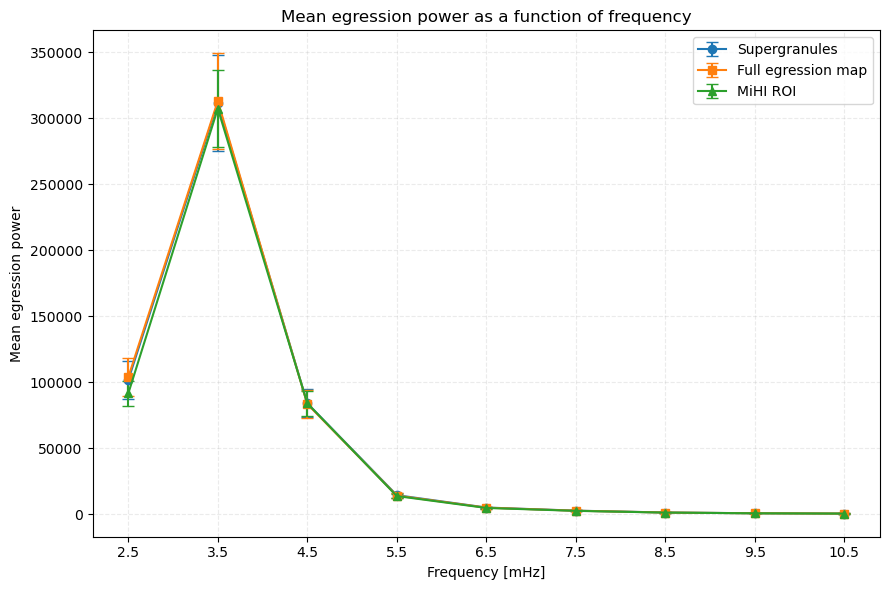

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# EJE X: FRECUENCIAS
# ============================================================

# Center of the frequency  bands:
# 2-3 -> 2.5 mHz, 3-4 -> 3.5 mHz, ..., 10-11 -> 10.5 mHz

freq_centers = np.arange(2.5, 11.0, 1.0)


# ============================================================
# FIGURA
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))


# ============================================================
# SUPERGRÁNULOS
# ============================================================

ax.errorbar(
    freq_centers,
    df["Supergranules mean"],
    yerr=df["Supergranules std"],
    marker="o",
    linestyle="-",
    capsize=4,
    label="Supergranules"
)


# ============================================================
# MAP
# ============================================================

ax.errorbar(
    freq_centers,
    df["Full map mean"],
    yerr=df["Full map std"],
    marker="s",
    linestyle="-",
    capsize=4,
    label="Full egression map"
)


# ============================================================
# ROI MiHI
# ============================================================

ax.errorbar(
    freq_centers,
    df["ROI mean"],
    yerr=df["ROI std"],
    marker="^",
    linestyle="-",
    capsize=4,
    label="MiHI ROI"
)


# ============================================================
# FORMAT
# ============================================================

ax.set_xlabel("Frequency [mHz]")
ax.set_ylabel("Mean egression power")

ax.set_xticks(freq_centers)

ax.legend()

ax.grid(
    alpha=0.25,
    linestyle="--"
)

ax.set_title(
    "Mean egression power as a function of frequency"
)

plt.tight_layout()
plt.show()

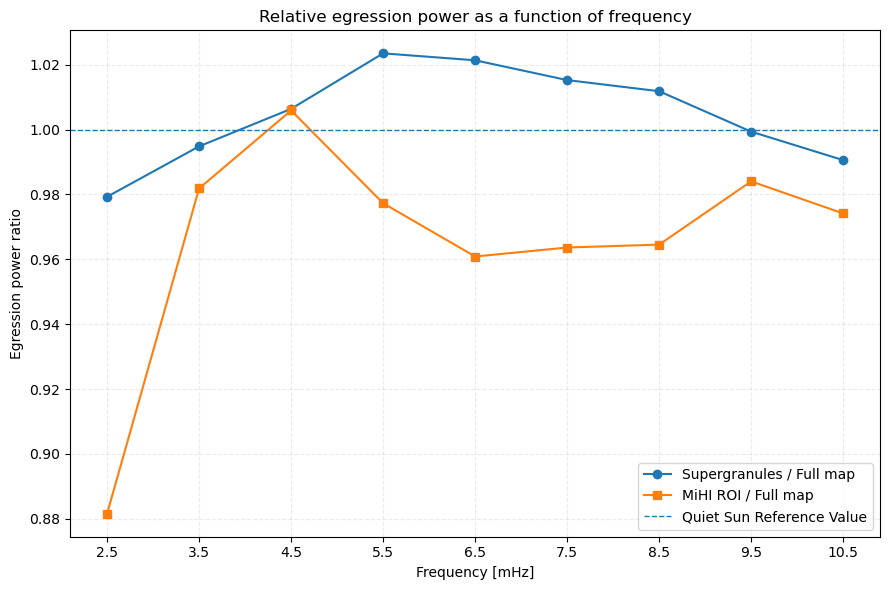

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CENTROS DE LAS BANDAS DE FRECUENCIA
# ============================================================

# 2-3 mHz -> 2.5 mHz
# 3-4 mHz -> 3.5 mHz
# ...
# 10-11 mHz -> 10.5 mHz

freq_centers = np.arange(2.5, 11.0, 1.0)


# ============================================================
# 2. CALCULAR LAS TRES RELACIONES
# ============================================================

R_sg_map = (
    df["Supergranules mean"].to_numpy()
    / df["Full map mean"].to_numpy()
)

R_roi_map = (
    df["ROI mean"].to_numpy()
    / df["Full map mean"].to_numpy()
)

#R_roi_sg = (
#    df["ROI mean"].to_numpy()
#    / df["Supergranules mean"].to_numpy()
#)


# ============================================================
# 3. GUARDARLAS TAMBIÉN EN EL DATAFRAME
# ============================================================

df["SG / Full map"] = R_sg_map
df["ROI / Full map"] = R_roi_map
#df["ROI / SG"] = R_roi_sg


# ============================================================
# 4. GRAFICAR
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    freq_centers,
    R_sg_map,
    marker="o",
    linestyle="-",
    label="Supergranules / Full map"
)

ax.plot(
    freq_centers,
    R_roi_map,
    marker="s",
    linestyle="-",
    label="MiHI ROI / Full map"
)
'''
ax.plot(
    freq_centers,
    R_roi_sg,
    marker="^",
    linestyle="-",
    label="MiHI ROI / Supergranules"
)
'''

# ============================================================
# 5. REFERENCIA: RATIO = 1
# ============================================================

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Quiet Sun Reference Value"
)


# ============================================================
# 6. FORMATO
# ============================================================

ax.set_xlabel("Frequency [mHz]")
ax.set_ylabel("Egression power ratio")

ax.set_xticks(freq_centers)

ax.set_title(
    "Relative egression power as a function of frequency"
)

ax.grid(
    alpha=0.25,
    linestyle="--"
)

ax.legend()

plt.tight_layout()
plt.show()

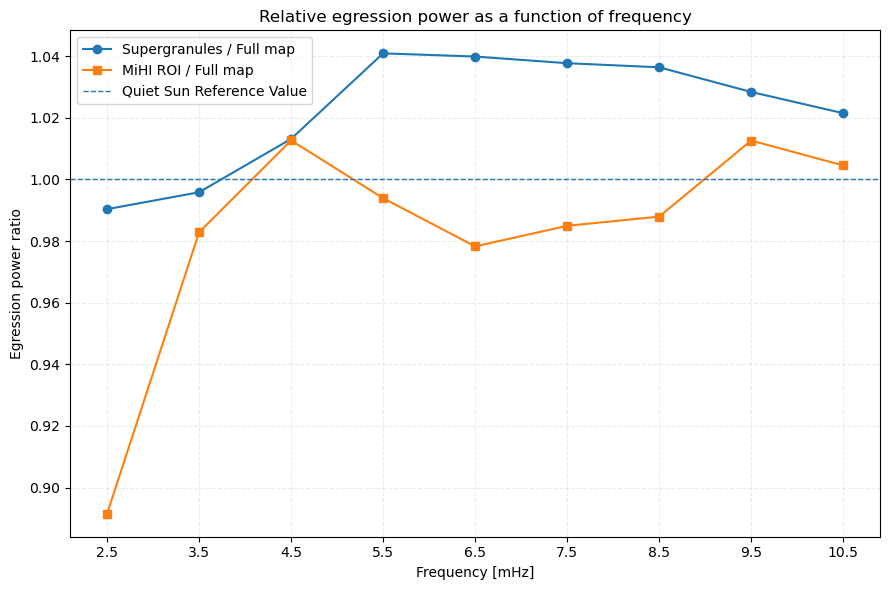

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. CENTROS DE LAS BANDAS DE FRECUENCIA
# ============================================================

# 2-3 mHz -> 2.5 mHz
# 3-4 mHz -> 3.5 mHz
# ...
# 10-11 mHz -> 10.5 mHz

freq_centers = np.arange(2.5, 11.0, 1.0)


# ============================================================
# 2. CALCULAR LAS TRES RELACIONES
# ============================================================

R_sg_map_cropped = (
    df["Supergranules mean"].to_numpy()
    / cropped_results_df["Cropped map mean"].to_numpy()
)

R_roi_map_cropped = (
    df["ROI mean"].to_numpy()
    / cropped_results_df["Cropped map mean"].to_numpy()
)

# ============================================================
# 3. GUARDARLAS TAMBIÉN EN EL DATAFRAME
# ============================================================

cropped_results_df["SG / Full map"] = R_sg_map_cropped
cropped_results_df["ROI / Full map"] = R_roi_map_cropped

# ============================================================
# 4. GRAFICAR
# ============================================================

fig, ax = plt.subplots(figsize=(9, 6))

ax.plot(
    freq_centers,
    R_sg_map_cropped,
    marker="o",
    linestyle="-",
    label="Supergranules / Full map"
)

ax.plot(
    freq_centers,
    R_roi_map_cropped,
    marker="s",
    linestyle="-",
    label="MiHI ROI / Full map"
)

# ============================================================
# 5. Quiet Sun Reference = 1
# ============================================================

ax.axhline(
    1.0,
    linestyle="--",
    linewidth=1,
    label="Quiet Sun Reference Value"
)


# ============================================================
# 6. FORMATO
# ============================================================

ax.set_xlabel("Frequency [mHz]")
ax.set_ylabel("Egression power ratio")

ax.set_xticks(freq_centers)

ax.set_title(
    "Relative egression power as a function of frequency (cropped maps)"
)

ax.grid(
    alpha=0.25,
    linestyle="--"
)

ax.legend()

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

# ============================================================
# COMPARACIÓN DE RATIOS: FULL MAP vs CROPPED MAP
# ============================================================

comparison_df = pd.DataFrame({
    "Frequency": df["Frequency"],

    # Supergránulos
    "SG / Full map": df["SG / Full map"],
    "SG / Cropped map": cropped_results_df["SG / Full map"],

    # ROI
    "ROI / Full map": df["ROI / Full map"],
    "ROI / Cropped map": cropped_results_df["ROI / Full map"],
})

# ============================================================
# CAMBIO PORCENTUAL AL USAR EL MAPA RECORTADO
# ============================================================

comparison_df["SG change (%)"] = (
    (comparison_df["SG / Cropped map"] /
     comparison_df["SG / Full map"] - 1) * 100
)

comparison_df["ROI change (%)"] = (
    (comparison_df["ROI / Cropped map"] /
     comparison_df["ROI / Full map"] - 1) * 100
)

comparison_df

,Frequency,SG / Full map,SG / Cropped map,ROI / Full map,ROI / Cropped map,SG change (%),ROI change (%)
0,2.0-3.0 mHz,0.979291,0.990363,0.881536,0.891503,1.130676,1.130676
1,3.0-4.0 mHz,0.994849,0.995847,0.981876,0.982860,0.100291,0.100291
2,4.0-5.0 mHz,1.006410,1.013170,1.005925,1.012682,0.671709,0.671697
3,5.0-6.0 mHz,1.023535,1.040932,0.977305,0.993916,1.699710,1.699710
4,6.0-7.0 mHz,1.021393,1.039894,0.960870,0.978275,1.811373,1.811385
5,7.0-8.0 mHz,1.015290,1.037738,0.963643,0.984950,2.211022,2.211022
6,8.0-9.0 mHz,1.011849,1.036399,0.964542,0.987944,2.426279,2.426279
7,9.0-10.0 mHz,0.999381,1.028404,0.984051,1.012629,2.904081,2.904093
8,10.0-11.0 mHz,0.990596,1.021503,0.974155,1.004549,3.120053,3.120065
